In [23]:
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import seaborn as sns
import pickle
from rich.progress import track

sns.set(color_codes=True, style="white")
# Roboto font path
# roboto_path = '/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/design/Roboto-Regular.ttf'

# import matplotlib.font_manager as fm

# # Create a FontProperties object
# roboto_font = fm.FontProperties(fname=roboto_path)

# # Add the font to the font manager's list
# fm.fontManager.addfont(roboto_path)

# plt.rcParams.update({'font.size': 18, 'figure.figsize': (10, 7), 'font.family': 'sans-serif', 'font.sans-serif': ['Roboto']})


### Load Data

In [24]:
# folder_PCF = "/Volumes/lsa-nwalter/Guoming_Gao_turbo/Walterlab_server/PROCESSED_DATA/RNA-in-HOPS_condensates/paper_figure_plots/PCF-protein"
folder_PCF = "/Volumes/lsa-nwalter/Sam_Husna_turbo/Data/HOPS-RNA-project/paper_figure_plots/PCF-protein"

os.chdir(folder_PCF)
p_files = [f for f in os.listdir(".") if f.endswith(".p")]
conditions = [f.split("PairCorr-DataDict-pooled-")[-1][:-2] for f in p_files]
conditions_ordered = [
    "eIF4E_2x",
    "RPS20_2x",
    "G3BP_2x",
    "CNOT1_2x",
    "eIF4E_1x",
    "RPS20_1x",
    "G3BP_1x",
    "CNOT1_1x",
]
colors = [
    "#739E87",  # eIF4E_2x
    "#276E48",  # RPS20_2x
    "#40DE8A",  # G3BP_2x
    "#20402F",  # CNOT1_2x
    "#BACFC4",  # eIF4E_1x
    "#79D0A2",  # RPS20_1x
    "#9FEFC4",  # G3BP_1x
    "#76BA95",  # CNOT1_1x
]

colors_dict = dict(zip(conditions_ordered, colors))
conditions_label_dict = {
    'eIF4E_2x': 'eIF4E',
    'RPS20_2x': 'RPS20',
    'G3BP_2x': 'G3BP',
    'CNOT1_2x': 'CNOT1',
    'eIF4E_1x': 'eIF4E',
    'RPS20_1x': 'RPS20',
    'G3BP_1x': 'G3BP',
    'CNOT1_1x': 'CNOT1',
}

# Four shades of red, blue, green.
red_shades = ["#DB7F8E", "#9A81B8", "#D9A675", "#7A9E9F"]
blue_shades = ["#6C9AC5", "#6DB89F", "#BBA56D", "#8D9FCA"]
green_shades = ["#78B383", "#C780A7", "#5FA5B3", "#B38E76"]

colors_dict = {
    "eIF4E_2x": red_shades[0],
    "RPS20_2x": blue_shades[0],
    "G3BP_2x": red_shades[1],
    "CNOT1_2x": blue_shades[1],
    "eIF4E_1x": red_shades[2],
    "RPS20_1x": blue_shades[3],
    "G3BP_1x": red_shades[3],
    "CNOT1_1x": blue_shades[2],
}

conditions_grouped = {
    'mRNA Translation Proteins_2x': ['eIF4E_2x', 'RPS20_2x'],
    'mRNA Translation Proteins_1x': ['eIF4E_1x', 'RPS20_1x'],
    'mRNA Decay Proteins_2x': ['G3BP_2x', 'CNOT1_2x'],
    'mRNA Decay Proteins_1x': ['G3BP_1x', 'CNOT1_1x'],
}


### Functions

In [25]:
def weighted_stats(lst_PCF_per_cell, lst_N_locations):
    # create arrays for weighted means, SEMs and STDs
    N_condensates = len(lst_N_locations)
    N_bins = lst_PCF_per_cell[0].shape[0]
    weighted_mean = np.zeros(N_bins)
    weighted_sem = np.zeros(N_bins)
    weighted_std = np.zeros(N_bins)
    weights = np.array(lst_N_locations)

    # iterate over the length of a numpy array in the list
    for i in range(N_bins):
        # extract the i-th element from each array and their respective weight
        data_array = np.array([lst_PCF_per_cell[j][i] for j in range(N_condensates)])
        # remove nan
        mask = np.isnan(data_array) | np.isnan(weights)
        data_array = data_array[~mask]
        # calculate the weighted mean
        weighted_mean[i] = np.average(data_array, weights=weights[~mask])
        # calculate the variance
        variance = np.average(
            (data_array - weighted_mean[i]) ** 2, weights=weights[~mask]
        )
        # calculate the weighted SEM
        weighted_sem[i] = np.sqrt(variance / N_condensates)
        # calculate the weighted STD
        weighted_std[i] = np.sqrt(variance)

    return weighted_mean, weighted_sem, weighted_std


def cluster_model(r, A, r0):
    # r0 is the characteristic size of clustering
    Gr = 1 + A * np.exp(-r / r0)
    return Gr


def coscos_PCF(r, a1, b1, c1, a2, b2, c2, d):
    # a is amplitude
    # b is wave number, also called the angular frequency
    # c is phase shift
    # d is vertical shift or rest position
    Gr = a1 * np.cos(b1 * r + c1) + a2 * np.cos(b2 * r + c2) + d
    return Gr


def red_chi(bins, A, r0, weighted_mean, weighted_std):
    # Calculate chi square
    Gr_fitted = cluster_model(bins, A, r0)
    residuals = weighted_mean - Gr_fitted
    variance = weighted_std**2
    chi_square = np.sum((residuals**2) / variance)
    # Calculate degrees of freedom
    dof = len(bins) - 2
    # Calculate reduced chi square
    reduced_chi_square = chi_square / dof
    return reduced_chi_square


def bootstrap(bins, lst_PCF_per_cell, lst_N_locations, bs_size=30, bs_rounds=100):
    lst_A = []
    lst_r0 = []
    lst_red_chi2 = []
    for i in range(bs_rounds):
        idxs = np.random.choice(len(lst_PCF_per_cell), bs_size)
        lst_PCF_bs = [lst_PCF_per_cell[idx] for idx in idxs]

        idxs = np.random.choice(len(lst_N_locations), bs_size)
        lst_N_bs = [lst_N_locations[idx] for idx in idxs]

        weighted_mean, _, weighted_std = weighted_stats(lst_PCF_bs, lst_N_bs)

        popt, _ = curve_fit(
            cluster_model,
            bins[1:],
            weighted_mean[1:],
            bounds=([-2, 0], [2, 2000]),
            maxfev=10000,
        )
        A, r0 = popt
        reduced_chi_square = red_chi(
            bins[1:], A, r0, weighted_mean[1:], weighted_std[1:]
        )

        lst_A.append(A)
        lst_r0.append(r0)
        lst_red_chi2.append(reduced_chi_square)

    return lst_A, lst_r0, lst_red_chi2

### cross weighted mean + STD

In [26]:
lst_mean = []
lst_sem = []
for i in track(range(len(conditions_ordered))):
    condition = conditions_ordered[i]
    dict_toplot = pickle.load(
        open("PairCorr-DataDict-pooled-" + condition + ".p", "rb")
    )
    nm_per_pxl = dict_toplot["nm_per_pxl"]
    r_max_nm = dict_toplot["r_max_nm"]
    ringwidth_nm = dict_toplot["ringwidth_nm"]
    dr_slidingrings_nm = dict_toplot["dr_slidingrings_nm"]
    bins = dict_toplot["bins"]

    # Calculate the weighted mean, STD, SEM
    lst_PCF_per_cell = dict_toplot["lst_cross"]
    lst_N_loc_condensate = dict_toplot["lst_N_loc_condensate"]
    lst_N_loc_protein = dict_toplot["lst_N_loc_protein"]
    lst_PCF_per_cell_norm = []
    lst_N_locations = []
    for current_PCF, a, b in zip(
        lst_PCF_per_cell, lst_N_loc_condensate, lst_N_loc_protein
    ):
        if np.mean(current_PCF[-10:]) == 0:
            continue
        lst_PCF_per_cell_norm.append(current_PCF / np.mean(current_PCF[-10:]))
        lst_N_locations.append(a + b)

    weighted_mean, weighted_sem, weighted_std = weighted_stats(
        lst_PCF_per_cell_norm, lst_N_locations
    )
    lst_mean.append(weighted_mean[0])
    lst_sem.append(weighted_sem[0])

    # Plot weighted mean curves + STD
    plt.figure(figsize=(4, 3))
    plt.axhline(1, c="gray", ls="--")
    plt.errorbar(
        bins,
        weighted_mean,
        yerr=weighted_sem,
        fmt="o",
        color=colors_dict[condition],
        ecolor=colors_dict[condition],
        elinewidth=1,
        capsize=2,
        ms=2.5,
    )
    plt.xlim(bins[0], bins[-1])
    plt.ylim(0.5, 2.5)
    plt.xlabel("r, nm", fontsize=17)
    plt.ylabel(r"G$_{cross}$(r)", fontsize=17)
    plt.gca().spines[:].set_linewidth(2)
    plt.gca().tick_params(
        axis="both",
        which="major",
        labelsize=17,
        direction="in",
        bottom=True,
        left=True,
        length=5,
        width=2,
    )

    plt.title(", ".join(condition.split("_")), fontsize=17, weight="bold")
    plt.savefig(
        "cross_PCF_" + condition + "_weighted_mean_SEM.png",
        format="png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.close()

Output()

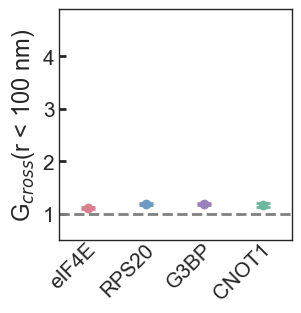

In [27]:
plt.figure(figsize=(3, 3))
x_pos = np.arange(len(conditions_ordered))
# lines for eyes
plt.axhline(1, c="gray", ls="--", lw=2)
plt.axvline((x_pos[3] + x_pos[4]) / 2, c="k", lw=0.5)
# plot

conditions_2x = conditions_ordered[:4]
conditions_2x_label = [conditions_label_dict[c] for c in conditions_2x]
conditions_1x = conditions_ordered[4:]
conditions_1x_label = [conditions_label_dict[c] for c in conditions_1x]

lst_mean_2x = lst_mean[:4]
lst_sem_2x = lst_sem[:4]
lst_mean_1x = lst_mean[4:]
lst_sem_1x = lst_sem[4:]
x_pos = np.arange(len(conditions_2x))

for i in range(len(conditions_2x)):
    condition = conditions_2x[i]
    plt.errorbar(
        x_pos[i],
        lst_mean_2x[i],
        yerr=lst_sem_2x[i],
        fmt="o",
        capsize=5,
        capthick=2,
        color=colors_dict[condition],
        ecolor=colors_dict[condition],
    )
    
# other settings
plt.ylabel(r"G$_{cross}$(r < 100 nm)", fontsize=17)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(
    axis="y",
    which="major",
    labelsize=15,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=2,
)
plt.gca().tick_params(
    axis="x",
    which="major",
    labelsize=15,
)
plt.xticks(
    x_pos + 0.2,
    conditions_2x_label,
    rotation=45,
    ha="right",
    y=0.06,
)
plt.xlim(x_pos[0] - 0.5, x_pos[-1] + 0.5)
plt.ylim(0.5, 4.9)

plt.savefig(
    "doterrorplot_firstbin_weighted_mean_SEM_2x.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)

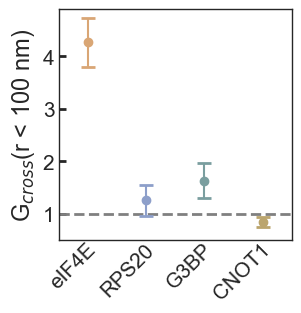

In [28]:
plt.figure(figsize=(3, 3))
x_pos = np.arange(len(conditions_ordered))
# lines for eyes
plt.axhline(1, c="gray", ls="--", lw=2)
plt.axvline((x_pos[3] + x_pos[4]) / 2, c="k", lw=0.5)
# plot
x_pos = np.arange(len(conditions_1x))
for i in range(len(conditions_1x)):
    condition = conditions_1x[i]
    plt.errorbar(
        x_pos[i],
        lst_mean_1x[i],
        yerr=lst_sem_1x[i],
        fmt="o",
        capsize=5,
        capthick=2,
        color=colors_dict[condition],
    )
# other settings
plt.ylabel(r"G$_{cross}$(r < 100 nm)", fontsize=17)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(
    axis="y",
    which="major",
    labelsize=15,
    direction="in",
    bottom=True,
    left=True,
    length=5,
    width=2,
)
plt.gca().tick_params(
    axis="x",
    which="major",
    labelsize=15,
)
plt.xticks(
    x_pos + 0.2,
    conditions_1x_label,
    rotation=45,
    ha="right",
    y=0.06,
)
plt.xlim(x_pos[0] - 0.5, x_pos[-1] + 0.5)
plt.ylim(0.5, 4.9)
plt.savefig(
    "doterrorplot_firstbin_weighted_mean_SEM_1x.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)

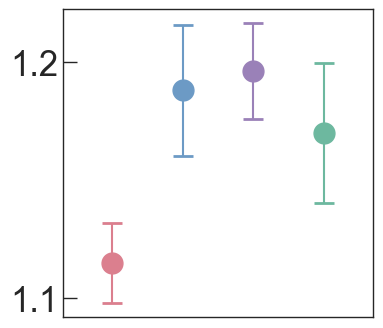

In [29]:
plt.figure(figsize=(4, 4))
x_pos = np.arange(len(conditions_ordered[:4]))
# lines for eyes
# plt.axhline(1, c="gray", ls="--", lw=2)
# plot
for i in range(len(conditions_ordered[:4])):
    condition = conditions_ordered[i]
    plt.errorbar(
        x_pos[i],
        lst_mean[i],
        yerr=lst_sem[i],
        fmt="o",
        ms=15,
        capsize=7,
        capthick=2,
        color=colors_dict[condition],
    )
# other settings
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(
    axis="y",
    which="major",
    labelsize=25,
    direction="in",
    bottom=True,
    left=True,
    length=10,
    width=1,
)
plt.xlim(x_pos[0] - 0.7, x_pos[-1] + 0.7)
plt.xticks([])
plt.yticks([1.1, 1.2])
plt.savefig(
    "inset_doterrorplot_firstbin_weighted_mean_SEM.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)

Output()

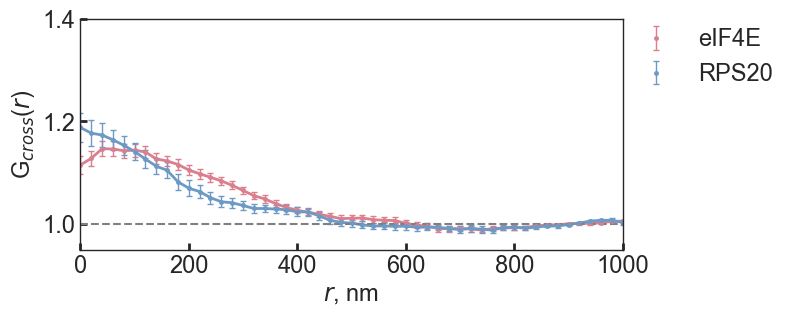

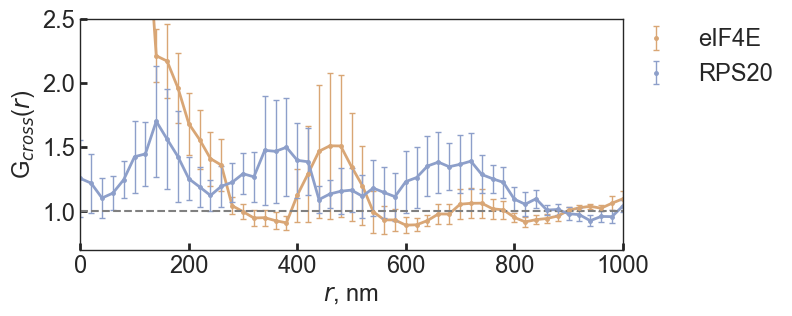

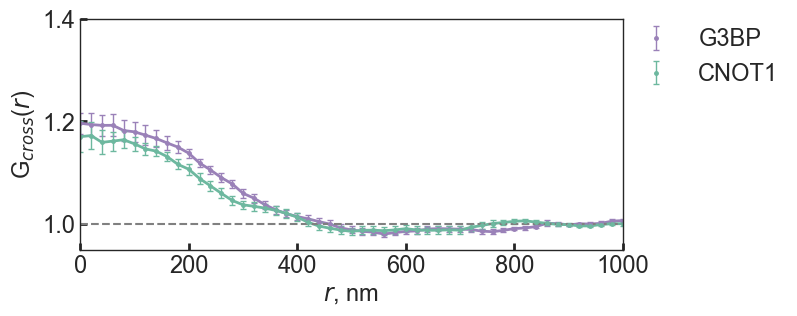

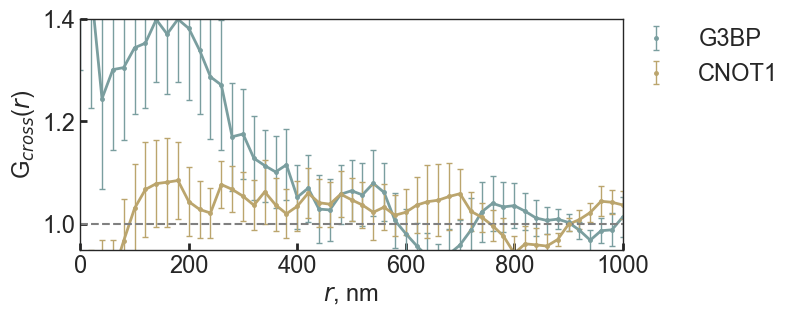

In [30]:
for i in track(range(len(conditions_grouped))):
    lst_mean = []
    lst_sem = []
    plt.figure(figsize=(7, 3))
    target_group = list(conditions_grouped.keys())[i]
    for condition in conditions_grouped[target_group]:
        dict_toplot = pickle.load(
            open("PairCorr-DataDict-pooled-" + condition + ".p", "rb")
        )
        nm_per_pxl = dict_toplot["nm_per_pxl"]
        r_max_nm = dict_toplot["r_max_nm"]
        ringwidth_nm = dict_toplot["ringwidth_nm"]
        dr_slidingrings_nm = dict_toplot["dr_slidingrings_nm"]
        bins = dict_toplot["bins"]

        # Calculate the weighted mean, STD, SEM
        lst_PCF_per_cell = dict_toplot["lst_cross"]
        lst_N_loc_condensate = dict_toplot["lst_N_loc_condensate"]
        lst_N_loc_RNA = dict_toplot["lst_N_loc_protein"]
        lst_PCF_per_cell_norm = []
        lst_N_locations = []
        for current_PCF, a, b in zip(lst_PCF_per_cell, lst_N_loc_condensate, lst_N_loc_RNA):
            if np.mean(current_PCF[-10:]) == 0:
                continue
            lst_PCF_per_cell_norm.append(current_PCF / np.mean(current_PCF[-10:]))
            lst_N_locations.append(a + b)

        weighted_mean, weighted_sem, weighted_std = weighted_stats(
            lst_PCF_per_cell_norm, lst_N_locations
        )

        color = colors_dict[condition]

        plt.errorbar(
            bins,
            weighted_mean,
            yerr=weighted_sem,
            fmt="o",
            color=color,
            ecolor=color,
            elinewidth=1,
            capsize=2,
            ms=2.5,
            label=conditions_label_dict[condition],
        )
        
        plt.plot(
            bins,
            weighted_mean,
            color=color,
            lw=2,
        )
        
        plt.xlim(bins[0], bins[-1])
        lst_mean.append(weighted_mean[0])
        lst_sem.append(weighted_sem[0])

    # Plot weighted mean curves + STD
    
    plt.axhline(1, c="gray", ls="--")

    if "Translation Proteins_1x" in target_group:
        plt.ylim(0.7, 2.5)
    else:
        plt.ylim(0.95, 1.4)
    plt.xlabel("$r$, nm", fontsize=17)
    plt.ylabel(r"G$_{cross}$($r$)", fontsize=17)
    plt.gca().spines[:].set_linewidth(1)
    plt.gca().tick_params(
        axis="both",
        which="major",
        labelsize=17,
        direction="in",
        bottom=True,
        left=True,
        length=5,
        width=2,
    )
    plt.legend(
        bbox_to_anchor=(1, 1),
        loc="upper left",
        borderaxespad=0.0,
        frameon=False,
        fontsize=17,
    )

    # plt.title(target_group.split("_")[0], fontsize=17)
    plt.savefig(
        "cross_PCF_comparison_" + target_group + ".svg",
        format="svg",
        bbox_inches="tight",
        dpi=300,
        transparent=True,
    )
    plt.show()

Output()

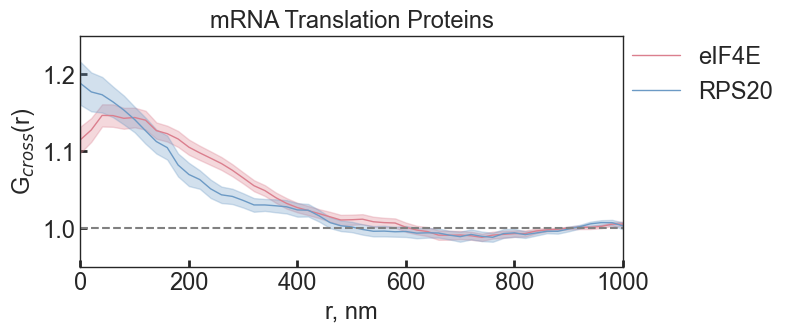

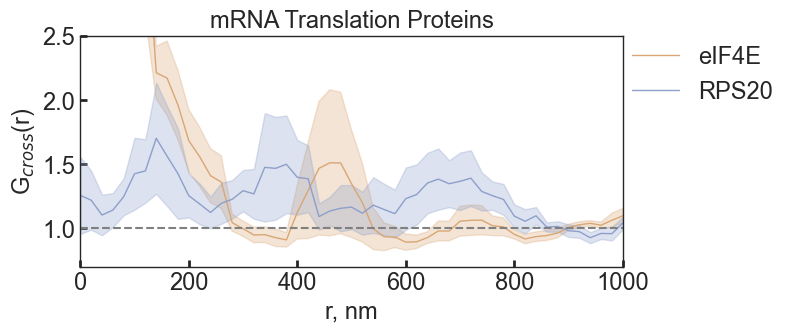

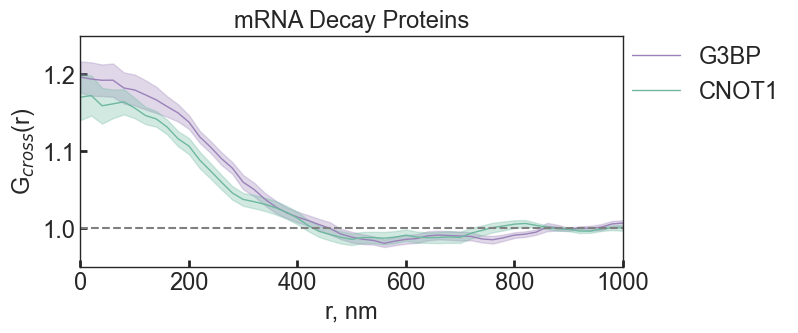

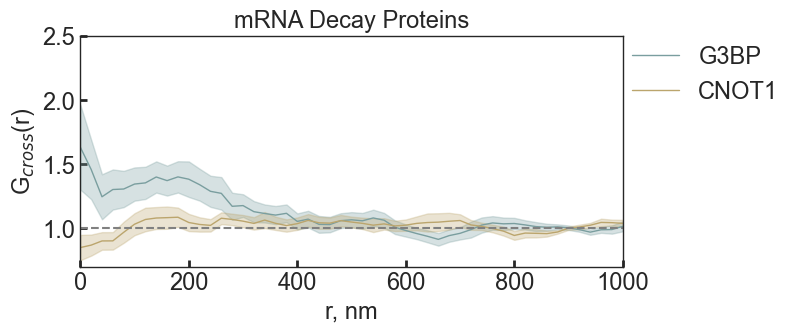

In [31]:
for i in track(range(len(conditions_grouped))):
    lst_mean = []
    lst_sem = []
    plt.figure(figsize=(7, 3))
    target_group = list(conditions_grouped.keys())[i]
    for condition in conditions_grouped[target_group]:
        dict_toplot = pickle.load(
            open("PairCorr-DataDict-pooled-" + condition + ".p", "rb")
        )
        nm_per_pxl = dict_toplot["nm_per_pxl"]
        r_max_nm = dict_toplot["r_max_nm"]
        ringwidth_nm = dict_toplot["ringwidth_nm"]
        dr_slidingrings_nm = dict_toplot["dr_slidingrings_nm"]
        bins = dict_toplot["bins"]

        # Calculate the weighted mean, STD, SEM
        lst_PCF_per_cell = dict_toplot["lst_cross"]
        lst_N_loc_condensate = dict_toplot["lst_N_loc_condensate"]
        lst_N_loc_RNA = dict_toplot["lst_N_loc_protein"]
        lst_PCF_per_cell_norm = []
        lst_N_locations = []
        for current_PCF, a, b in zip(lst_PCF_per_cell, lst_N_loc_condensate, lst_N_loc_RNA):
            if np.mean(current_PCF[-10:]) == 0:
                continue
            lst_PCF_per_cell_norm.append(current_PCF / np.mean(current_PCF[-10:]))
            lst_N_locations.append(a + b)

        weighted_mean, weighted_sem, weighted_std = weighted_stats(
            lst_PCF_per_cell_norm, lst_N_locations
        )

        color = colors_dict[condition]

        # plt.scatter(
        #     bins,
        #     weighted_mean,
        #     color=color,
        #     label=conditions_label_dict[condition],
        #     s=5
        # )

        plt.fill_between(
            bins,
            weighted_mean - weighted_sem,
            weighted_mean + weighted_sem,
            color=color,
            alpha=0.3,
        )
        
        plt.plot(
            bins,
            weighted_mean,
            color=color,
            lw=1,
            label=conditions_label_dict[condition],
        )
        
        plt.xlim(bins[0], bins[-1])
        lst_mean.append(weighted_mean[0])
        lst_sem.append(weighted_sem[0])

    # Plot weighted mean curves + STD
    
    plt.axhline(1, c="gray", ls="--")

    if "1x" in target_group:
        plt.ylim(0.7, 2.5)
    else:
        plt.ylim(0.95, 1.25)
    plt.xlabel("r, nm", fontsize=17)
    plt.ylabel(r"G$_{cross}$(r)", fontsize=17)
    plt.gca().spines[:].set_linewidth(1)
    plt.gca().tick_params(
        axis="both",
        which="major",
        labelsize=17,
        direction="in",
        bottom=True,
        left=True,
        length=5,
        width=2,
    )
    plt.legend(
        bbox_to_anchor=(1, 1),
        loc="upper left",
        borderaxespad=0.0,
        frameon=False,
        fontsize=17,
    )

    plt.title(target_group.split("_")[0], fontsize=17)
    plt.savefig(
        "cross_PCF_comparison_" + target_group + "_fb.svg",
        format="svg",
        bbox_inches="tight",
        dpi=300,
        transparent=True,
    )
    plt.show()